# Modeling Notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
import itertools
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
import os
print(os.getcwd())


/Users/chrispapesh/Desktop/Sports Health AI/Urgent-Heat/Capstone-Nevada-Heat-Impact


In [4]:
# Load overdose + weather merged dataset
try:
    overdose_df = pd.read_csv(
        '../Data/Overdose Data/overdose_weather_merge.csv',
        parse_dates=["admit_datetime"]
    )
    print(f"Loaded overdose data: {len(overdose_df)} rows")
except FileNotFoundError:
    print("Note: overdose_weather_merge.csv not found. Models will be skipped.")
    overdose_df = pd.DataFrame()

# --- Load Heat Related Deaths Data ---
import os

HEAT_CSV_PATHS = [
    'Heat_Related_2021-2024.csv',
    '../Data/Heat_Related_2021-2024.csv',
    '../Data/Heat Related Deaths/Heat_Related_2021-2024.csv',
]

HEAT_EXCEL_FILES = [
    'Heat_Related_2024_EOY_Coroner-dataset.xlsx',
    'Heat Related 2024 EOY Coroner-dataset.xlsx',
    'Heat_Deaths_EOY_2025__1_.xlsx',
    'Heat_Deaths_EOY_2025.xlsx',
    'Heat Deaths EOY 2025.xlsx',
    '../Data/Heat_Related_2024_EOY_Coroner-dataset.xlsx',
    '../Data/Heat Related 2024 EOY Coroner-dataset.xlsx',
    '../Data/Heat_Deaths_EOY_2025__1_.xlsx',
    '../Data/Heat Deaths EOY 2025.xlsx',
]

try:
    frames = []
    csv_loaded = False
    for csv_path in HEAT_CSV_PATHS:
        if os.path.exists(csv_path):
            base_df = pd.read_csv(csv_path)
            frames.append(base_df)
            csv_loaded = True
            print(f"Loaded baseline CSV: {csv_path} ({len(base_df)} rows)")
            break

    seen_xl = set()
    for xl_path in HEAT_EXCEL_FILES:
        real = os.path.realpath(xl_path) if os.path.exists(xl_path) else None
        if real and real not in seen_xl and os.path.exists(xl_path):
            seen_xl.add(real)
            xl_df = pd.read_excel(xl_path)
            frames.append(xl_df)
            print(f"Loaded Excel file: {xl_path} ({len(xl_df)} rows)")

    if not frames:
        raise FileNotFoundError("No heat-related deaths source file found.")

    heat_df = pd.concat(frames, ignore_index=True, sort=False)
    before = len(heat_df)
    heat_df.drop_duplicates(subset=['Case #'], keep='first', inplace=True)
    print(f"After dedup: {len(heat_df)} records ({before - len(heat_df)} removed)")

    heat_df['Date of Death'] = pd.to_datetime(heat_df['Date of Death'], errors='coerce')
    heat_df = heat_df.dropna(subset=['Date of Death'])

    daily_heat_deaths = (
        heat_df.groupby('Date of Death')
        .size()
        .rename('heat_death_count')
        .reset_index()
    )
    daily_heat_deaths.rename(columns={'Date of Death': 'date'}, inplace=True)
    daily_heat_deaths['date'] = pd.to_datetime(daily_heat_deaths['date']).dt.date

    print(f"Success: {len(heat_df)} records, "
          f"{heat_df['Date of Death'].min().date()} to {heat_df['Date of Death'].max().date()}")

except Exception as e:
    print(f"Warning: Could not load heat related deaths: {e}")
    daily_heat_deaths = pd.DataFrame(columns=['date', 'heat_death_count'])


Note: overdose_weather_merge.csv not found. Models will be skipped.
Loaded Excel file: Heat Related 2024 EOY Coroner-dataset.xlsx (472 rows)
After dedup: 472 records (0 removed)
Success: 472 records, 2024-04-22 to 2024-11-25


Time Series Modeling

In [5]:
# STEP 1: Define relevant weather variables
weather_vars = [
    "temperature_2m_f", "relative_humidity_2m_", "dew_point_2m_f",
    "apparent_temperature_f", "snowfall_inch", "rain_inch",
    "precipitation_inch", "wind_speed_10m_mph", "wet_bulb_temperature_2m_f",
    "uv_index_", "uv_index_clear_sky_"
]

# STEP 2: Ensure datetime format
if not overdose_df.empty:
    overdose_df["date"] = pd.to_datetime(overdose_df["admit_datetime"]).dt.date
    # STEP 3: Create daily overdose counts
    daily_counts = overdose_df.groupby("date").size().rename("incident_count").reset_index()
    # STEP 4: Compute daily averages of weather features
    daily_weather = overdose_df.groupby("date")[weather_vars].mean().reset_index()
    # STEP 5: Merge counts + weather
    daily_overdose_ts = pd.merge(daily_counts, daily_weather, on="date")
else:
    # Initialize empty TS if overdose data is missing
    daily_overdose_ts = pd.DataFrame(columns=["date", "incident_count"] + weather_vars)

# STEP 6: Merge with Heat Related Deaths
daily_overdose_ts = pd.merge(daily_overdose_ts, daily_heat_deaths, on="date", how="outer").fillna(0)

numeric_cols = ["incident_count", "heat_death_count"] + weather_vars
for col in numeric_cols:
    if col in daily_overdose_ts.columns:
        daily_overdose_ts[col] = pd.to_numeric(daily_overdose_ts[col], errors="coerce").fillna(0)

# STEP 7: Final formatting
daily_overdose_ts["date"] = pd.to_datetime(daily_overdose_ts["date"])
daily_overdose_ts.set_index("date", inplace=True)
daily_overdose_ts.sort_index(inplace=True)


/var/folders/jf/kbm0d7zs4js4gyf_vz0zjb9c0000gn/T/ipykernel_64683/2762379661.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  daily_overdose_ts = pd.merge(daily_overdose_ts, daily_heat_deaths, on="date", how="outer").fillna(0)


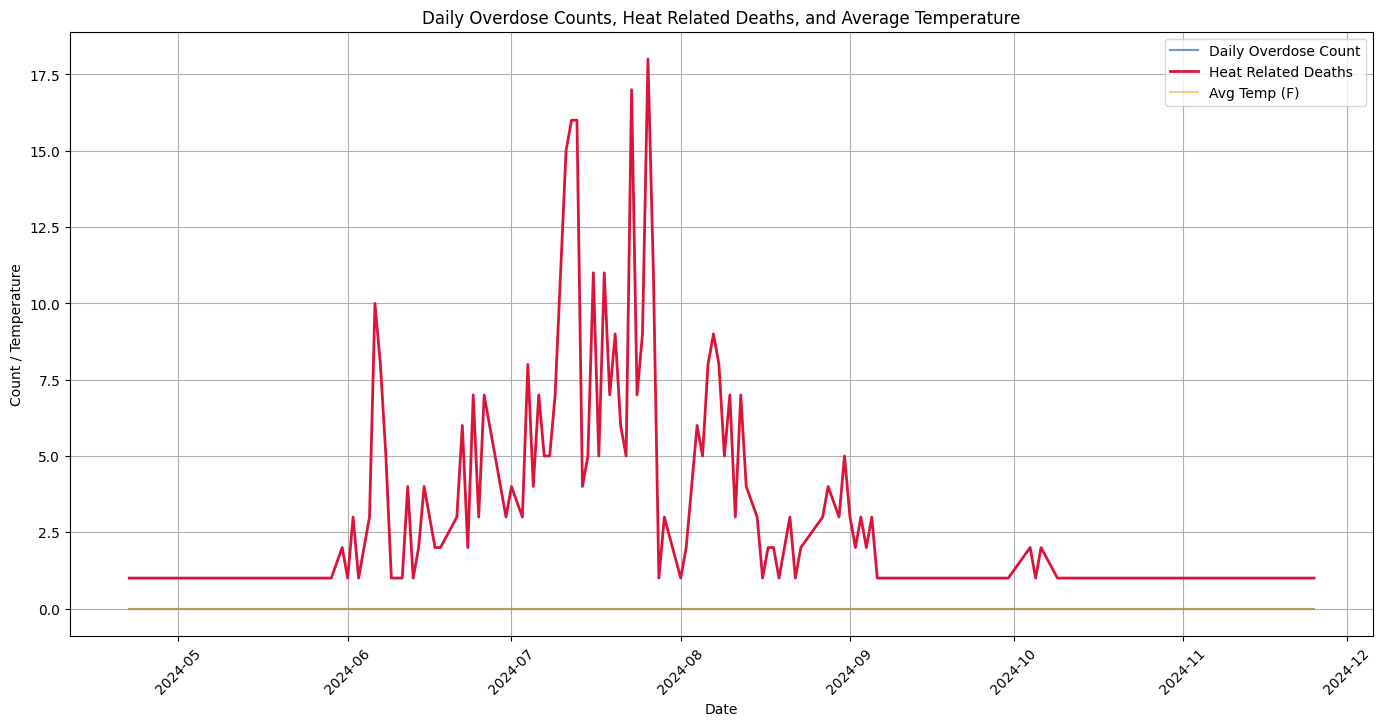

In [6]:
# Plot: Overdoses, Heat Deaths, and Temperature
plt.figure(figsize=(14, 7))

sns.lineplot(data=daily_overdose_ts, x="date", y="incident_count", label="Daily Overdose Count", color="steelblue", alpha=0.8)
sns.lineplot(data=daily_overdose_ts, x="date", y="heat_death_count", label="Heat Related Deaths", color="crimson", linewidth=2)
sns.lineplot(data=daily_overdose_ts, x="date", y="temperature_2m_f", label="Avg Temp (F)", color="orange", alpha=0.5)

plt.title("Daily Overdose Counts, Heat Related Deaths, and Average Temperature")
plt.xlabel("Date")
plt.ylabel("Count / Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

Stationarity Testing

In [7]:
from statsmodels.tsa.stattools import adfuller

# Plot original series
if not daily_overdose_ts["incident_count"].empty and daily_overdose_ts["incident_count"].sum() > 0:
    daily_overdose_ts["incident_count"].plot(figsize=(14, 5), title="Original Overdose Count Time Series")
    plt.grid(True)
    plt.show()
else:
    print("Skipping plot: No numeric incident data available.")

# Check stationarity with Augmented Dickey-Fuller test
result = adfuller(daily_overdose_ts["incident_count"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])


Skipping plot: No numeric incident data available.


ValueError: Invalid input, x is constant

p-value < 0.05, so we **reject** the null hypothesis of non-stationarity and proceed with ARIMA Modeling

In [ ]:


# Define p, d, q ranges
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

# Grid search
for order in pdq:
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            model = ARIMA(daily_overdose_ts["incident_count"], order=order)
            results = model.fit()
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_model = results
    except:
        continue

print(f"Best ARIMA order: {best_order} with AIC: {best_aic}")


Best ARIMA order: (2, 1, 1) with AIC: 11410.461358684108


### Model 1: ARIMA (Univariate, No Exogenous Variables)

In [ ]:
# Fit best model
final_model = ARIMA(daily_overdose_ts["incident_count"], order=(2, 1, 1))
final_results = final_model.fit()

# Summary
print(final_results.summary())


c:\Users\big_d\anaconda3\envs\Complete_ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\big_d\anaconda3\envs\Complete_ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\big_d\anaconda3\envs\Complete_ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1827
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -5701.231
Date:                Wed, 11 Jun 2025   AIC                          11410.461
Time:                        12:25:37   BIC                          11432.501
Sample:                    01-01-2020   HQIC                         11418.591
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0711      0.024      2.930      0.003       0.024       0.119
ar.L2          0.0517      0.024      2.149      0.032       0.005       0.099
ma.L1         -0.9469      0.008   -117.507      0.0

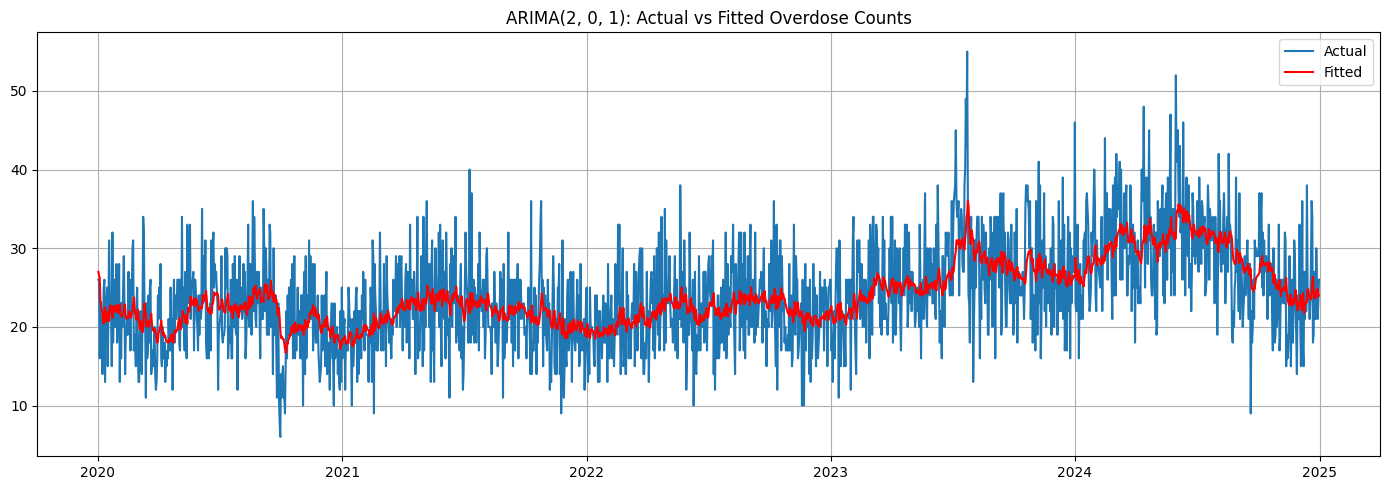

In [ ]:
# Generate in-sample predictions
fitted = final_results.predict(start=1, end=len(daily_overdose_ts)-1, typ='levels')

# Get ARIMA order
order = (
    final_results.model_orders.get("ar", 0),
    final_results.model_orders.get("diff", 0),
    final_results.model_orders.get("ma", 0)
)

# Plot Actual vs Fitted
plt.figure(figsize=(14, 5))
plt.plot(daily_overdose_ts.index[1:], daily_overdose_ts["incident_count"].iloc[1:], label="Actual")
plt.plot(daily_overdose_ts.index[1:], fitted, label="Fitted", color="red")
plt.title(f"ARIMA{order}: Actual vs Fitted Overdose Counts")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [ ]:


mae = mean_absolute_error(daily_overdose_ts["incident_count"].iloc[1:], fitted)
rmse = np.sqrt(mean_squared_error(daily_overdose_ts["incident_count"].iloc[1:], fitted))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 4.42
RMSE: 5.49


### Model 2: ARIMAX via SARIMAX (Temperature Only, No Seasonality)


In [ ]:
sarimax_model = SARIMAX(
    daily_overdose_ts["incident_count"],
    order=(2, 1, 1),
    exog=daily_overdose_ts[["temperature_2m_f"]]
)
sarimax_results = sarimax_model.fit()
print(sarimax_results.summary())


c:\Users\big_d\anaconda3\envs\Complete_ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\big_d\anaconda3\envs\Complete_ML\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1827
Model:               SARIMAX(2, 1, 1)   Log Likelihood               -5688.529
Date:                Wed, 11 Jun 2025   AIC                          11387.059
Time:                        12:25:38   BIC                          11414.608
Sample:                    01-01-2020   HQIC                         11397.221
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
temperature_2m_f     0.0835      0.016      5.226      0.000       0.052       0.115
ar.L1                0.0675      0.024      2.792      0.005       0.020       0.115
ar.L2                0.0503 

### Model 3: SARIMAX Grid Search (Temperature Only)

In [ ]:


# Define p, d, q ranges
p = d = q = range(0, 4)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

# Suppress convergence and frequency warnings
warnings.filterwarnings("ignore")

# Grid search over SARIMAX configurations
for order in pdq:
    try:
        model = SARIMAX(
            daily_overdose_ts["incident_count"],
            order=order,
            exog=daily_overdose_ts[["temperature_2m_f"]],
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except Exception as e:
        continue  # You may log `e` if you want to debug specific failures

print(f"✅ Best SARIMAX order (with temperature): {best_order} — AIC: {best_aic:.2f}")


✅ Best SARIMAX order (with temperature): (3, 1, 3) — AIC: 11350.11


In [ ]:
# Summary of the best model
print(best_model.summary())


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1827
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5667.055
Date:                Wed, 11 Jun 2025   AIC                          11350.110
Time:                        12:26:15   BIC                          11394.172
Sample:                    01-01-2020   HQIC                         11366.365
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
temperature_2m_f     0.0831      0.016      5.358      0.000       0.053       0.113
ar.L1               -0.3024      0.210     -1.439      0.150      -0.714       0.109
ar.L2                0.0233 

### Model 4: SARIMAX (Multiple Weather Variables)

In [ ]:
exog_vars = daily_overdose_ts[["temperature_2m_f", "uv_index_", "wind_speed_10m_mph"]]

model = SARIMAX(
    daily_overdose_ts["incident_count"],
    order=(2, 1, 1),
    exog=exog_vars
)
results = model.fit()
print(results.summary())


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1827
Model:               SARIMAX(2, 1, 1)   Log Likelihood               -5686.483
Date:                Wed, 11 Jun 2025   AIC                          11386.965
Time:                        12:26:16   BIC                          11425.535
Sample:                    01-01-2020   HQIC                         11401.192
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
temperature_2m_f       0.1004      0.018      5.449      0.000       0.064       0.137
uv_index_             -0.4397      0.222     -1.979      0.048      -0.875      -0.004
wind_speed_10m_mph  

## Correlation Matrix

In [ ]:
# Compute correlation matrix including the new heat death count
correlations = daily_overdose_ts.corr(numeric_only=True)["incident_count"].sort_values(ascending=False)
print("Correlations with Incident Count:")
print(correlations)

heat_correlations = daily_overdose_ts.corr(numeric_only=True)["heat_death_count"].sort_values(ascending=False)
print("\nCorrelations with Heat Related Deaths:")
print(heat_correlations)

incident_count               1.000000
apparent_temperature_f       0.202697
temperature_2m_f             0.201728
uv_index_clear_sky_          0.196503
uv_index_                    0.196282
wet_bulb_temperature_2m_f    0.196220
dew_point_2m_f               0.126983
precipitation_inch           0.035930
rain_inch                    0.035922
wind_speed_10m_mph           0.022201
snowfall_inch                0.001007
relative_humidity_2m_       -0.068499
Name: incident_count, dtype: float64


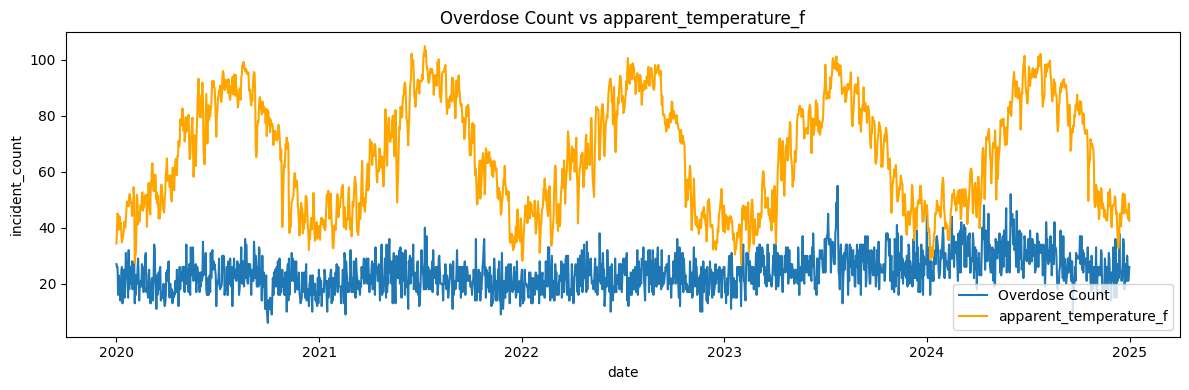

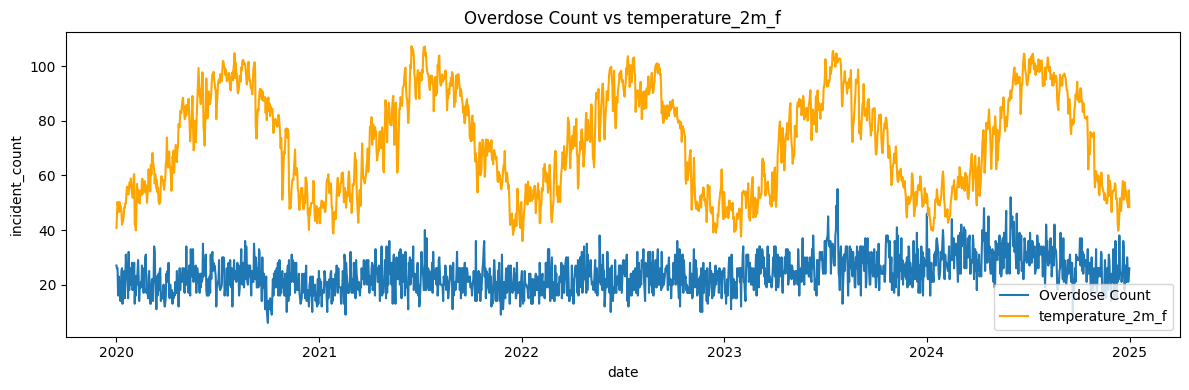

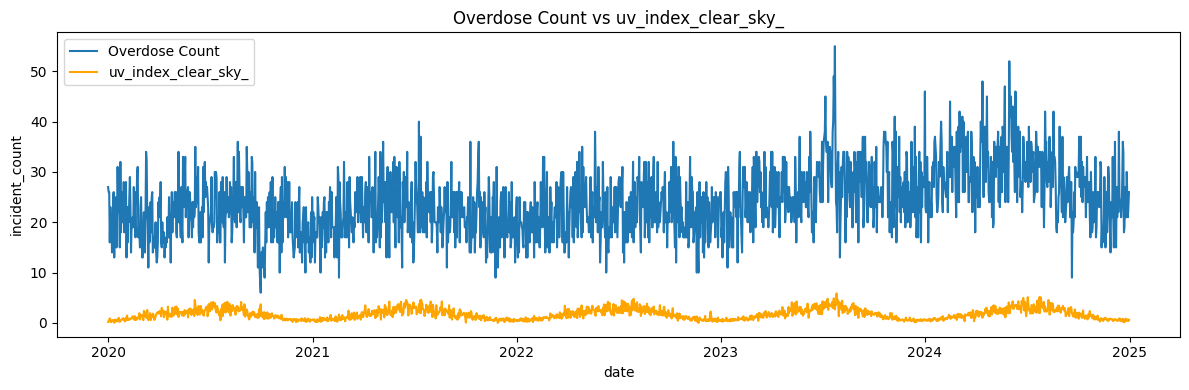

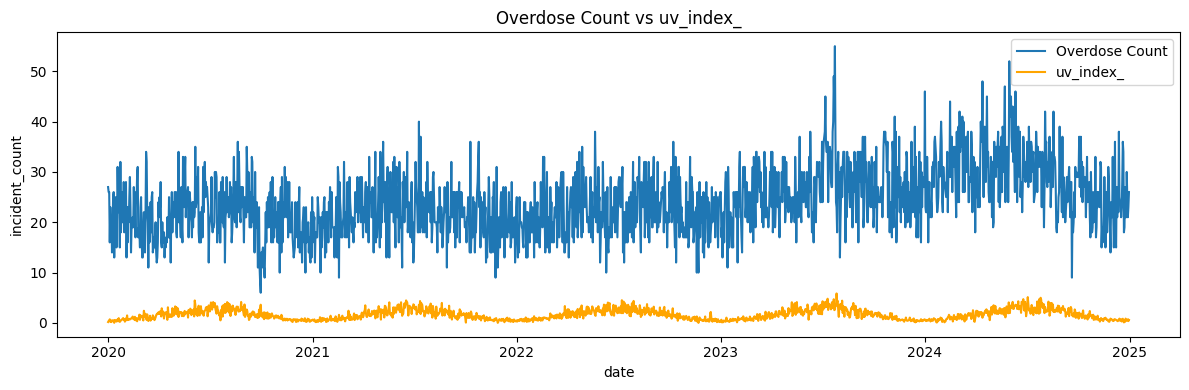

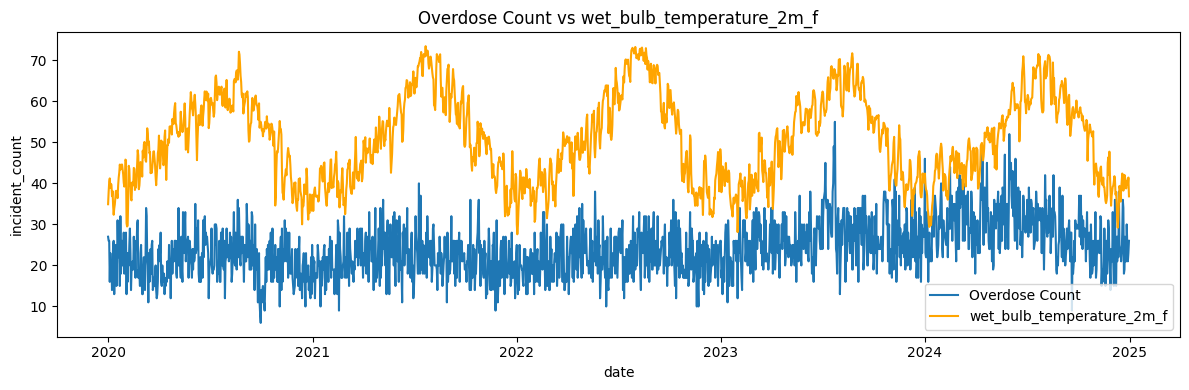

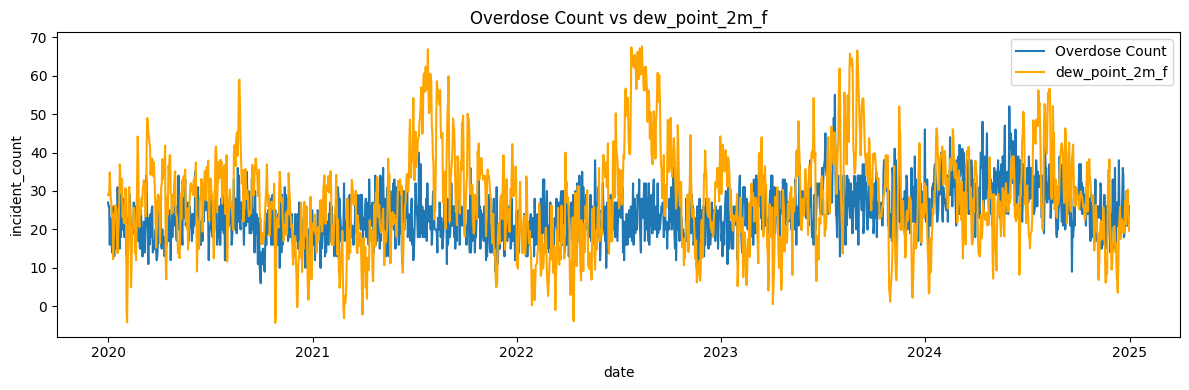

In [ ]:
top_vars = correlations[1:7].index  # Skip the first (self-correlation)

for var in top_vars:
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=daily_overdose_ts, x=daily_overdose_ts.index, y="incident_count", label="Overdose Count")
    sns.lineplot(data=daily_overdose_ts, x=daily_overdose_ts.index, y=var, label=var, color='orange')
    plt.title(f"Overdose Count vs {var}")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Model 5: SARIMAX (Top 6 Correlated Weather Features)

In [ ]:
exog_vars_top6 = daily_overdose_ts[[
    "apparent_temperature_f", "temperature_2m_f", "uv_index_clear_sky_",
    "uv_index_", "wet_bulb_temperature_2m_f", "dew_point_2m_f"
]]

exog_vars_top3 = daily_overdose_ts[[
    "apparent_temperature_f", "temperature_2m_f", "uv_index_clear_sky_"
]]



In [ ]:
model = SARIMAX(
    daily_overdose_ts["incident_count"],
    order=(3, 1, 3),  # or the best order found from grid search
    exog=exog_vars_top3
)
results = model.fit()
print(results.summary())


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1827
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5677.353
Date:                Wed, 11 Jun 2025   AIC                          11374.706
Time:                        12:26:19   BIC                          11429.805
Sample:                    01-01-2020   HQIC                         11395.031
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0556      0.056      0.986      0.324      -0.055       0.166
temperature_2m_f           0.0437      0.061      0.714      0.475      -0.076       0.164
uv_i

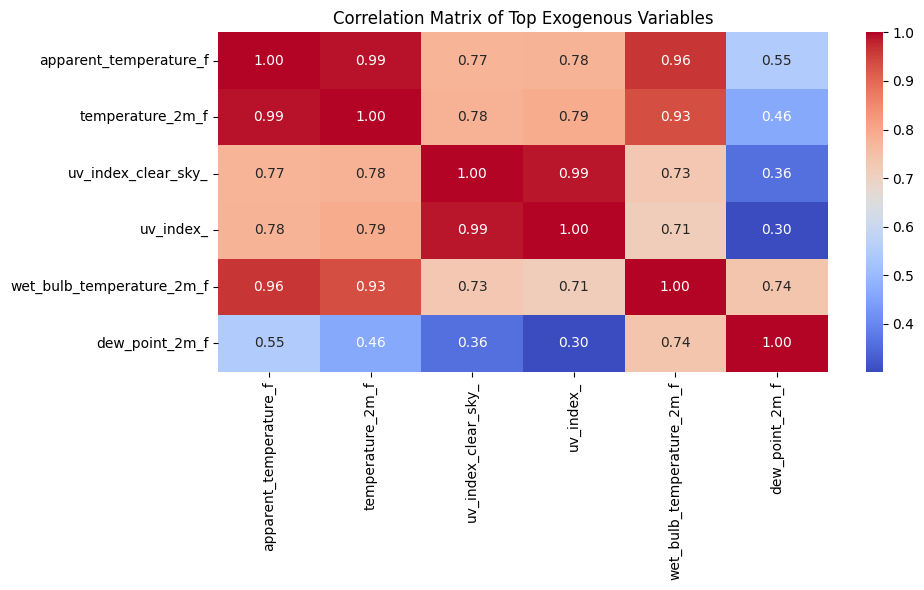

In [ ]:
# Check for multicollinearity among top variables
import seaborn as sns
corr_matrix = exog_vars_top6.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Top Exogenous Variables")
plt.tight_layout()
plt.show()


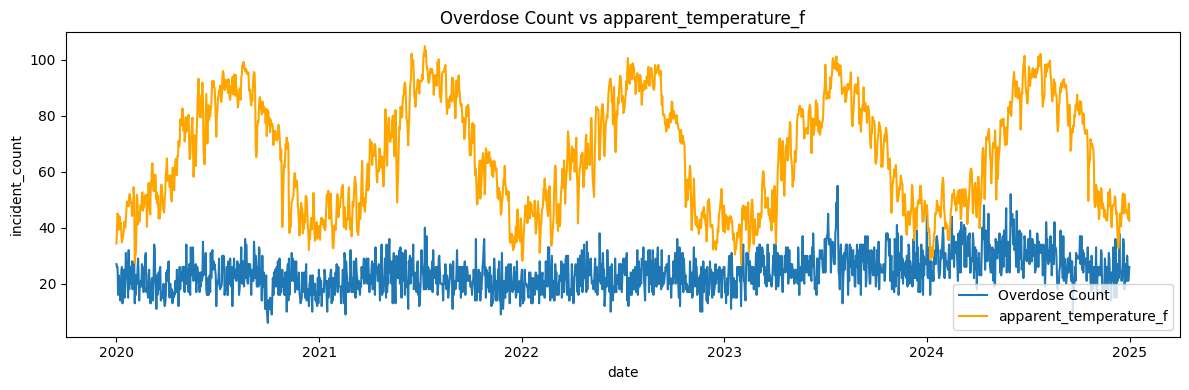

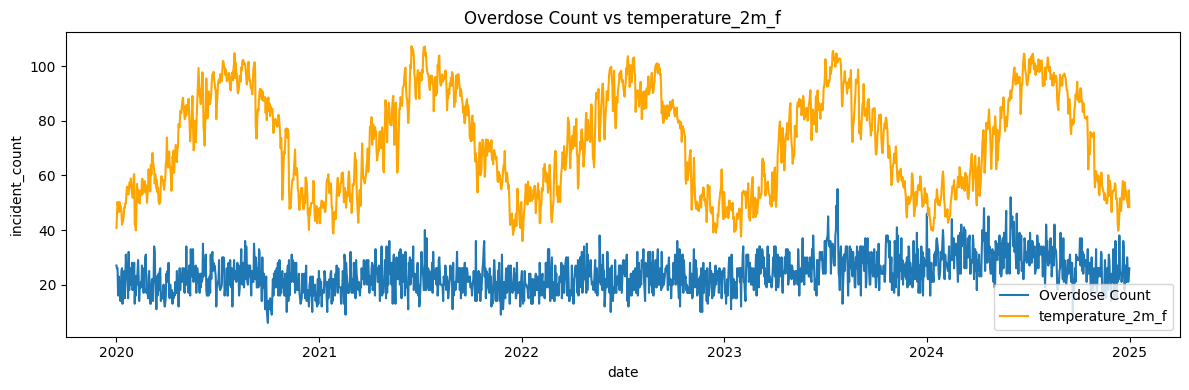

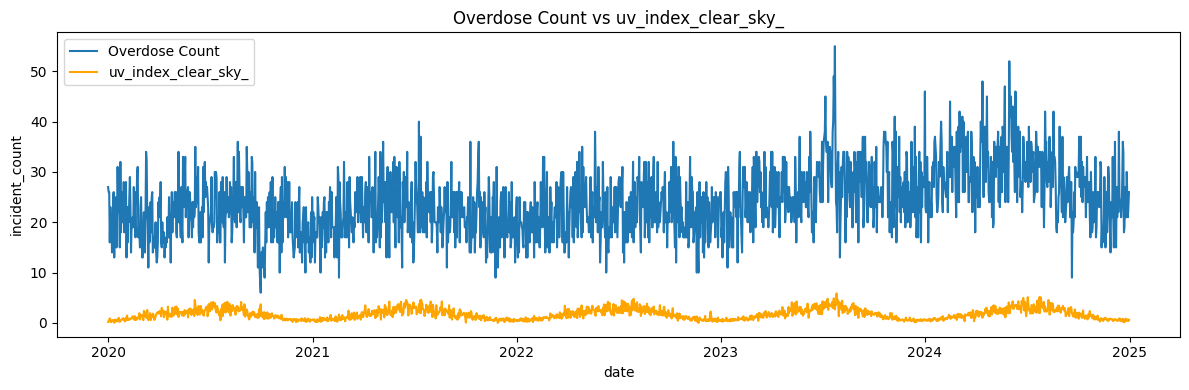

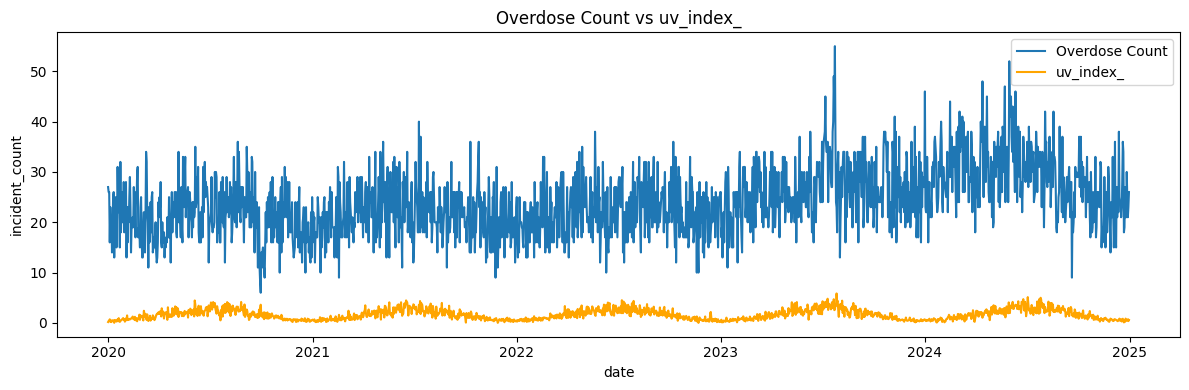

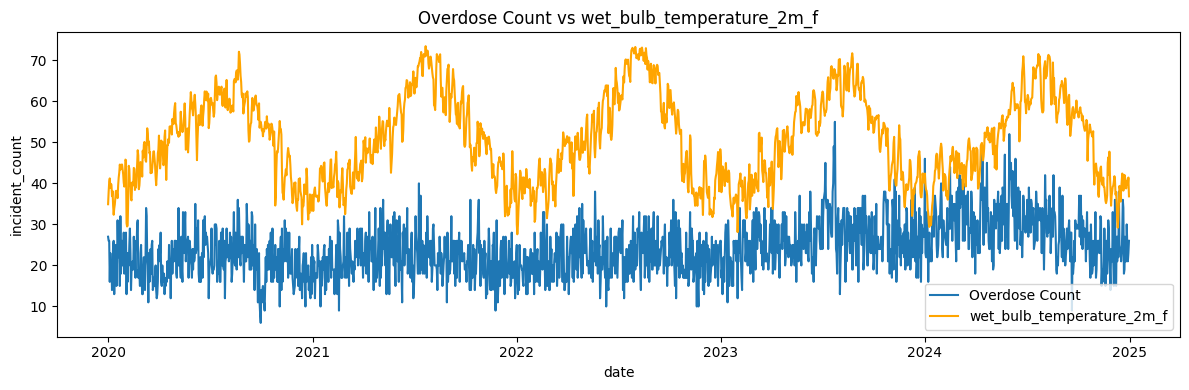

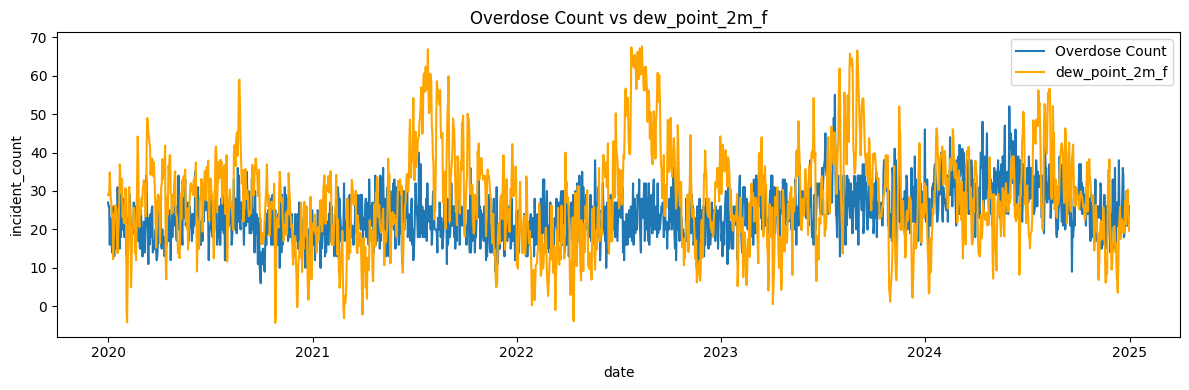

In [ ]:
top_vars = correlations[1:7].index  # Skip the first (self-correlation)

for var in top_vars:
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=daily_overdose_ts, x=daily_overdose_ts.index, y="incident_count", label="Overdose Count")
    sns.lineplot(data=daily_overdose_ts, x=daily_overdose_ts.index, y=var, label=var, color='orange')
    plt.title(f"Overdose Count vs {var}")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings

# Define search space
p = d = q = range(0, 4)
pdq = list(itertools.product(p, d, q))

# Use all defined weather variables
exog_vars = daily_overdose_ts[[
    "temperature_2m_f", "relative_humidity_2m_", "dew_point_2m_f",
    "apparent_temperature_f", "snowfall_inch", "rain_inch",
    "precipitation_inch", "wind_speed_10m_mph", "wet_bulb_temperature_2m_f",
    "uv_index_", "uv_index_clear_sky_"
]]

best_aic = np.inf
best_order = None
best_model = None

# Suppress convergence and frequency warnings
warnings.filterwarnings("ignore")

# Grid search over SARIMAX configurations
for order in pdq:
    try:
        model = SARIMAX(
            daily_overdose_ts["incident_count"],
            order=order,
            exog=exog_vars,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except Exception:
        continue

print(f"✅ Best SARIMAX order (with all weather vars): {best_order} — AIC: {best_aic:.2f}")



✅ Best SARIMAX order (with all weather vars): (3, 1, 3) — AIC: 11359.94


In [ ]:
exog_vars_refined = daily_overdose_ts[[
    "apparent_temperature_f",
    "uv_index_clear_sky_",
    "dew_point_2m_f"
]]


In [ ]:
model = SARIMAX(
    daily_overdose_ts["incident_count"],
    order=(3, 1, 3),  # still using the best order found
    exog=exog_vars_refined
)
results = model.fit()
print(results.summary())


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1827
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5677.572
Date:                Wed, 11 Jun 2025   AIC                          11375.144
Time:                        12:28:36   BIC                          11430.243
Sample:                    01-01-2020   HQIC                         11395.468
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0929      0.018      5.035      0.000       0.057       0.129
uv_index_clear_sky_       -0.4783      0.219     -2.189      0.029      -0.907      -0.050
dew_

In [ ]:
exog_vars_trimmed = daily_overdose_ts[[
    "apparent_temperature_f",
    "uv_index_clear_sky_"
]]

model_trimmed = SARIMAX(
    daily_overdose_ts["incident_count"],
    order=(3, 1, 3),
    exog=exog_vars_trimmed
)
results_trimmed = model_trimmed.fit()
print(results_trimmed.summary()) # type: ignore


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1827
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5677.572
Date:                Wed, 11 Jun 2025   AIC                          11373.144
Time:                        12:28:38   BIC                          11422.733
Sample:                    01-01-2020   HQIC                         11391.436
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0929      0.017      5.568      0.000       0.060       0.126
uv_index_clear_sky_       -0.4780      0.217     -2.199      0.028      -0.904      -0.052
ar.L

## Feature Engineering to Potentially Decrease AIC

Temperatures > 90 for two consecutive days constitute heatwaves!!

In [ ]:
# Boolean Series for temp > 90
is_hot_90 = daily_overdose_ts["temperature_2m_f"] > 90

# Rolling window for 3-day hot streaks
daily_overdose_ts["mod_heatwave"] = is_hot_90.rolling(window=3).sum() >= 3
daily_overdose_ts["mod_heatwave"] = daily_overdose_ts["mod_heatwave"].astype(int)


In [ ]:
# Boolean Series for temp > 105
is_hot_105 = daily_overdose_ts["temperature_2m_f"] > 105

# Rolling window for 5-day extreme heat streaks
daily_overdose_ts["ext_heatwave"] = is_hot_105.rolling(window=5).sum() >= 5
daily_overdose_ts["ext_heatwave"] = daily_overdose_ts["ext_heatwave"].astype(int)


### Model 6: SARIMAX (Heatwave Feature Engineering)

In [ ]:
exog_heatwave = daily_overdose_ts[[
    "apparent_temperature_f",
    "uv_index_clear_sky_",
    "mod_heatwave"
]]

sarimax_heatwave_model = SARIMAX(
    daily_overdose_ts["incident_count"],
    order=(3, 1, 3),
    exog=exog_heatwave
)
results_heatwave = sarimax_heatwave_model.fit()
print(results_heatwave.summary())


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1827
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5674.007
Date:                Wed, 11 Jun 2025   AIC                          11368.015
Time:                        12:28:41   BIC                          11423.114
Sample:                    01-01-2020   HQIC                         11388.339
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0777      0.018      4.344      0.000       0.043       0.113
uv_index_clear_sky_       -0.4990      0.218     -2.294      0.022      -0.925      -0.073
mod_

We now know that including a moderate heatwave variable improves our model marginally while adding the extreme heatwave negates that improvement due to collinearity.

Adding Lag Features: Lag Overdose and Lag Weather variables

In [ ]:
daily_overdose_ts["lag1"] = daily_overdose_ts["incident_count"].shift(1)
daily_overdose_ts["lag7"] = daily_overdose_ts["incident_count"].shift(7)  # Weekly pattern

Moving Averages/Rolling Means

In [ ]:
daily_overdose_ts["rolling_mean_3"] = daily_overdose_ts["incident_count"].rolling(3).mean()
daily_overdose_ts["rolling_mean_7"] = daily_overdose_ts["incident_count"].rolling(7).mean()


High UV Flags

In [ ]:
daily_overdose_ts["high_uv_flag"] = (daily_overdose_ts["uv_index_"] >= 6).astype(int)

Or temperature buckets/bins

In [ ]:
daily_overdose_ts["temp_category"] = pd.cut(
    daily_overdose_ts["temperature_2m_f"],
    bins=[-np.inf, 60, 75, 90, np.inf],
    labels=["cold", "mild", "warm", "hot"]
)

Remove NA's

In [ ]:
daily_overdose_ts.dropna(inplace=True)


Dummy variables for temp_category

In [ ]:
temp_dummies = pd.get_dummies(daily_overdose_ts["temp_category"], prefix="temp", drop_first=True)

Interaction Terms:
- apparent_temperature_f * uv_index_clear_sky
- heatwave_flag * uv_index_clear_sky

In [ ]:
daily_overdose_ts["temp_uv_interaction"] = (
    daily_overdose_ts["apparent_temperature_f"] * daily_overdose_ts["uv_index_clear_sky_"]
)

daily_overdose_ts["heat_uv_interaction"] = (
    daily_overdose_ts["mod_heatwave"] * daily_overdose_ts["uv_index_clear_sky_"]
)


Combining All Engineered Features

In [ ]:
# Recreate exog_enhanced BEFORE dropping rows
exog_enhanced = pd.concat([
    daily_overdose_ts[[
        "apparent_temperature_f", "uv_index_clear_sky_", "mod_heatwave",
        "lag1", "lag7", "rolling_mean_3", "rolling_mean_7",
        "high_uv_flag", "temp_uv_interaction", "heat_uv_interaction",
        "heat_death_count"
    ]],
    pd.get_dummies(daily_overdose_ts["temp_category"], prefix="temp", drop_first=True)
], axis=1)

# ✅ Convert all bool columns (from get_dummies) to int
exog_enhanced = exog_enhanced.astype({col: int for col in exog_enhanced.select_dtypes("bool").columns})

# Drop rows with NaNs (after rolling/lags introduced them)
combined = pd.concat([daily_overdose_ts["incident_count"], exog_enhanced], axis=1).dropna()

# Now safely extract aligned target and exog
aligned_target = combined["incident_count"]
exog_enhanced = combined.drop(columns=["incident_count"])

# ✅ Final dtype check (should now pass)
assert exog_enhanced.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all(), "Non-numeric dtypes remain!"


### Model 7: Enhanced SARIMAX (Lags, Rolling Means, Interactions, Dummies)

In [ ]:
sarimax_enhanced = SARIMAX(
    aligned_target,
    order=(3, 1, 3),
    exog=exog_enhanced
)
enhanced_results = sarimax_enhanced.fit()
print(enhanced_results.summary())

                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1820
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5056.532
Date:                Wed, 11 Jun 2025   AIC                          10153.064
Time:                        12:28:44   BIC                          10263.185
Sample:                    01-08-2020   HQIC                         10193.692
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0136      0.010      1.413      0.158      -0.005       0.032
uv_index_clear_sky_        0.1454      0.209      0.696      0.486      -0.264       0.555
mod_

Comparing AICs

In [ ]:
print("AIC (Enhanced Model):", enhanced_results.aic)
print("Log Likelihood:", enhanced_results.llf)


AIC (Enhanced Model): 10153.063942591021
Log Likelihood: -5056.531971295511


14-day Forecast

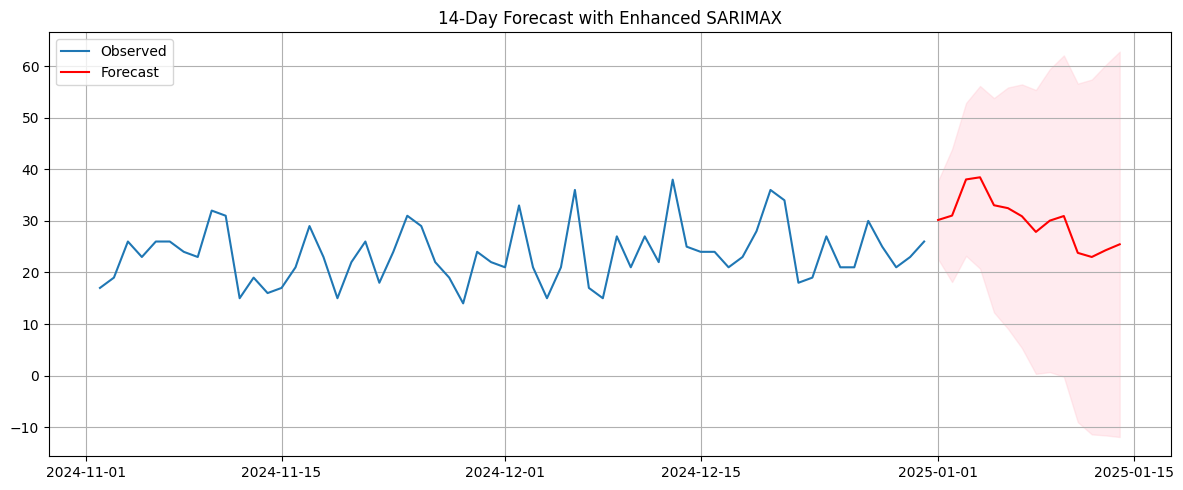

In [ ]:
forecast = enhanced_results.get_forecast(steps=14, exog=exog_enhanced.tail(14))
forecast_ci = forecast.conf_int()
forecast_mean = forecast.predicted_mean

plt.figure(figsize=(12, 5))
plt.plot(aligned_target[-60:], label="Observed")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="red")
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color="pink", alpha=0.3)
plt.title("14-Day Forecast with Enhanced SARIMAX")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Residual Diagnostics

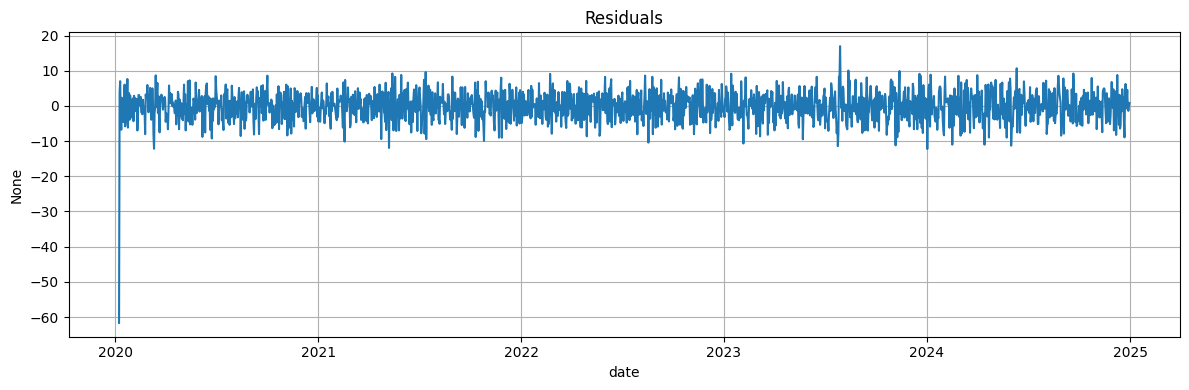

In [ ]:
residuals = enhanced_results.resid
plt.figure(figsize=(12, 4))
plt.title("Residuals")
sns.lineplot(x=residuals.index, y=residuals)
plt.grid(True)
plt.tight_layout()
plt.show()

MAE/RMSE

In [ ]:
mae = mean_absolute_error(aligned_target, enhanced_results.fittedvalues)
rmse = np.sqrt(mean_squared_error(aligned_target, enhanced_results.fittedvalues))
print(f"Enhanced MAE: {mae:.2f}, RMSE: {rmse:.2f}")

Enhanced MAE: 3.17, RMSE: 4.16


## Upgrade Implementation for SARIMAX Modeling


### Upgrade 1: SARIMAX with Seasonality (Weekly Patterns)


In [ ]:
model_with_seasonality = SARIMAX(
    aligned_target,
    order=(3, 1, 3),
    seasonal_order=(1, 0, 1, 7),
    exog=exog_enhanced
)
results_with_seasonality = model_with_seasonality.fit()
print(results_with_seasonality.summary())


                                      SARIMAX Results                                      
Dep. Variable:                      incident_count   No. Observations:                 1820
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 7)   Log Likelihood               -5062.943
Date:                             Wed, 11 Jun 2025   AIC                          10169.886
Time:                                     12:28:51   BIC                          10291.019
Sample:                                 01-08-2020   HQIC                         10214.577
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0145      0.012      1.256      0.209      -0.008    

### Upgrade 2: Adding Lagged Weather Features


In [ ]:
daily_overdose_ts["temp_lag1"] = daily_overdose_ts["temperature_2m_f"].shift(1)
daily_overdose_ts["uv_lag1"] = daily_overdose_ts["uv_index_clear_sky_"].shift(1)
exog_enhanced["temp_lag1"] = daily_overdose_ts["temp_lag1"]
exog_enhanced["uv_lag1"] = daily_overdose_ts["uv_lag1"]

# Redrop NA and align
combined = pd.concat([daily_overdose_ts["incident_count"], exog_enhanced], axis=1).dropna()
aligned_target = combined["incident_count"]
exog_enhanced = combined.drop(columns=["incident_count"])


### Upgrade 3: Adding Calendar-Based Features (Weekdays, Holidays)


In [ ]:
daily_overdose_ts["weekday"] = daily_overdose_ts.index.dayofweek

# Create cyclical encoding of weekday (0=Monday, 6=Sunday)
daily_overdose_ts["dow_sin"] = np.sin(2 * np.pi * daily_overdose_ts["weekday"] / 7)
daily_overdose_ts["dow_cos"] = np.cos(2 * np.pi * daily_overdose_ts["weekday"] / 7)

# Add to exogenous variables
exog_enhanced["dow_sin"] = daily_overdose_ts["dow_sin"]
exog_enhanced["dow_cos"] = daily_overdose_ts["dow_cos"]


import holidays
us_holidays = holidays.US()
daily_overdose_ts["is_holiday"] = daily_overdose_ts.index.to_series().apply(lambda d: d in us_holidays).astype(int)
exog_enhanced["is_holiday"] = daily_overdose_ts["is_holiday"]

# Re-align again
combined = pd.concat([daily_overdose_ts["incident_count"], exog_enhanced], axis=1).dropna()
aligned_target = combined["incident_count"]
exog_enhanced = combined.drop(columns=["incident_count"])


### Upgrade 4: Train-Test Split to Evaluate Forecasting

In [ ]:
# 🧼 Step 1: Remove duplicate columns
exog_enhanced = exog_enhanced.loc[:, ~exog_enhanced.columns.duplicated()]

# 🔄 Step 2: Convert all boolean columns to integers
bool_cols = exog_enhanced.select_dtypes(include="bool").columns
exog_enhanced[bool_cols] = exog_enhanced[bool_cols].astype(int)

# ✅ Step 3: Assert everything is numeric
assert exog_enhanced.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all(), "Still contains non-numeric values!"

# 🔁 Step 4: Re-align target and predictors
combined = pd.concat([aligned_target, exog_enhanced], axis=1).dropna()
aligned_target = combined["incident_count"]
exog_enhanced = combined.drop(columns=["incident_count"])



In [ ]:
train_size = int(0.85 * len(aligned_target))
train_y = aligned_target[:train_size]
train_X = exog_enhanced[:train_size]
test_y = aligned_target[train_size:]
test_X = exog_enhanced[train_size:]

model_tt = SARIMAX(train_y, order=(3, 1, 3), seasonal_order=(1, 0, 1, 7), exog=train_X)
results_tt = model_tt.fit()

preds = results_tt.predict(start=test_y.index[0], end=test_y.index[-1], exog=test_X)

mae_tt = mean_absolute_error(test_y, preds)
rmse_tt = np.sqrt(mean_squared_error(test_y, preds))
print(f"Test MAE: {mae_tt:.2f}, RMSE: {rmse_tt:.2f}")


Test MAE: 9.53, RMSE: 11.52


### Upgrade 5: Feature Importance via Permutation (OLS Proxy)

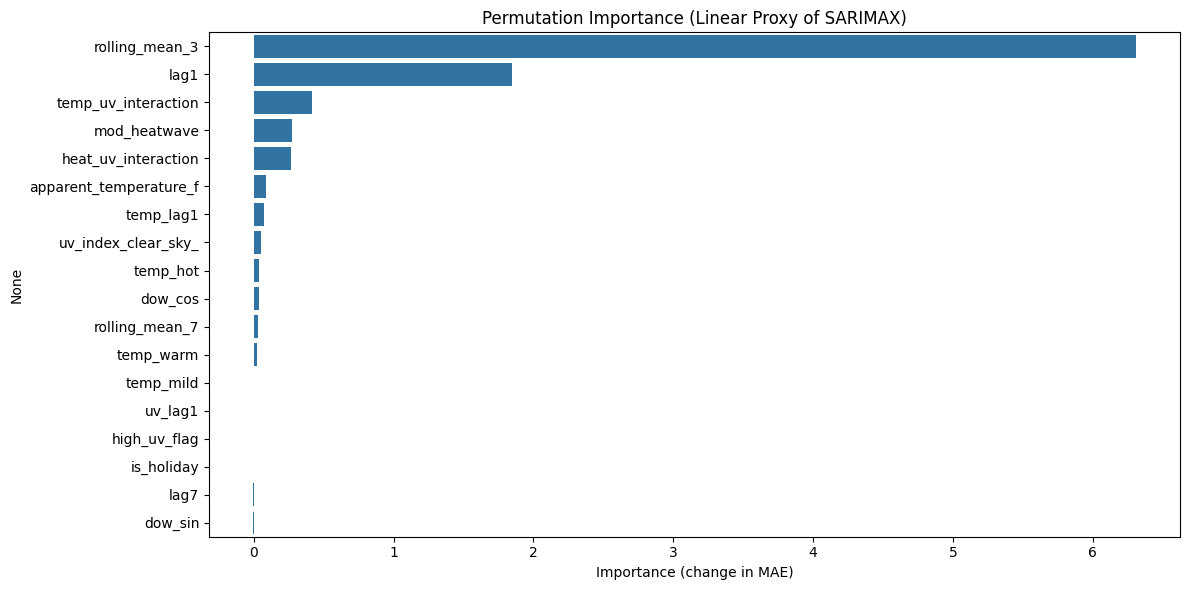

In [ ]:


ols_model = LinearRegression()
ols_model.fit(train_X, train_y)

perm_result = permutation_importance(
    ols_model, test_X, test_y,
    scoring='neg_mean_absolute_error',
    n_repeats=30,
    random_state=42
)

import matplotlib.pyplot as plt
import seaborn as sns

sorted_idx = perm_result.importances_mean.argsort()[::-1]
plt.figure(figsize=(12,6))
sns.barplot(x=perm_result.importances_mean[sorted_idx], y=test_X.columns[sorted_idx])
plt.title("Permutation Importance (Linear Proxy of SARIMAX)")
plt.xlabel("Importance (change in MAE)")
plt.tight_layout()
plt.show()


## Classification Model

### Base Models

Can we build a model to predict high risk days? Below will be a classification model converting the target variable to a binary. Days >= 20 are "High Risk Days":

In [ ]:
daily_overdose_ts["high_od"] = (daily_overdose_ts["incident_count"] >= 20).astype(int)


Prep!

In [ ]:
# Step 1: Create binary classification target
y_class = daily_overdose_ts.loc[exog_enhanced.index, "high_od"]
X_class = exog_enhanced.copy()

# Step 2: Split into training and testing sets (same 85/15 ratio)
train_size = int(0.85 * len(X_class))
X_train, X_test = X_class[:train_size], X_class[train_size:]
y_train, y_test = y_class[:train_size], y_class[train_size:]

# Check shape
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (1546, 18) Test shape: (273, 18)


#### Logistic Regression

In [ ]:
# Step 1: Train Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Step 2: Predict
y_pred_log = logreg.predict(X_test)

# Step 3: Evaluate
acc_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)
report_log = classification_report(y_test, y_pred_log)

print(f"🔍 Logistic Regression Accuracy: {acc_log:.2f}")
print("\n🧱 Confusion Matrix:\n", cm_log)
print("\n📋 Classification Report:\n", report_log)


🔍 Logistic Regression Accuracy: 0.91

🧱 Confusion Matrix:
 [[  6  18]
 [  7 242]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.25      0.32        24
           1       0.93      0.97      0.95       249

    accuracy                           0.91       273
   macro avg       0.70      0.61      0.64       273
weighted avg       0.89      0.91      0.90       273



#### Naive Bayes

In [ ]:
# Step 1: Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Step 2: Predict
y_pred_nb = nb.predict(X_test)

# Step 3: Evaluate
acc_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb)

print(f"🔍 Naive Bayes Accuracy: {acc_nb:.2f}")
print("\n🧱 Confusion Matrix:\n", cm_nb)
print("\n📋 Classification Report:\n", report_nb)


🔍 Naive Bayes Accuracy: 0.86

🧱 Confusion Matrix:
 [[ 12  12]
 [ 25 224]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.50      0.39        24
           1       0.95      0.90      0.92       249

    accuracy                           0.86       273
   macro avg       0.64      0.70      0.66       273
weighted avg       0.89      0.86      0.88       273



#### Random Forest

In [ ]:
# Step 1: Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Step 2: Predict
y_pred_rf = rf.predict(X_test)

# Step 3: Evaluate
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"🔍 Random Forest Accuracy: {acc_rf:.2f}")
print("\n🧱 Confusion Matrix:\n", cm_rf)
print("\n📋 Classification Report:\n", report_rf)


🔍 Random Forest Accuracy: 0.90

🧱 Confusion Matrix:
 [[  3  21]
 [  5 244]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.12      0.19        24
           1       0.92      0.98      0.95       249

    accuracy                           0.90       273
   macro avg       0.65      0.55      0.57       273
weighted avg       0.87      0.90      0.88       273



### Secondary Models - Oversampled

These models have been oversampled and refit.

In [ ]:
# Apply oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print("Resampled shape:", X_resampled.shape)
print("Class distribution:", pd.Series(y_resampled).value_counts())


Resampled shape: (2212, 18)
Class distribution: high_od
0    1106
1    1106
Name: count, dtype: int64


#### Logistic Regression

In [ ]:

# Refit model
logreg_balanced = LogisticRegression(max_iter=1000)
logreg_balanced.fit(X_resampled, y_resampled)

# Predict on test set
y_pred_balanced = logreg_balanced.predict(X_test)

# Evaluation
print("🔍 Logistic Regression (Oversampled) Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\n🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_balanced))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred_balanced))


🔍 Logistic Regression (Oversampled) Accuracy: 0.8901098901098901

🧱 Confusion Matrix:
 [[ 10  14]
 [ 16 233]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.42      0.40        24
           1       0.94      0.94      0.94       249

    accuracy                           0.89       273
   macro avg       0.66      0.68      0.67       273
weighted avg       0.89      0.89      0.89       273



#### Naive Bayes

In [ ]:
# Refit Naive Bayes on oversampled data
nb_balanced = GaussianNB()
nb_balanced.fit(X_resampled, y_resampled)

# Predict on test set
y_pred_nb = nb_balanced.predict(X_test)

# Evaluate
print("🔍 Naive Bayes (Oversampled) Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\n🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred_nb))


🔍 Naive Bayes (Oversampled) Accuracy: 0.8315018315018315

🧱 Confusion Matrix:
 [[ 15   9]
 [ 37 212]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.62      0.39        24
           1       0.96      0.85      0.90       249

    accuracy                           0.83       273
   macro avg       0.62      0.74      0.65       273
weighted avg       0.90      0.83      0.86       273



#### Random Forest

In [ ]:
# Refit Random Forest on oversampled data
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_balanced.fit(X_resampled, y_resampled)

# Predict on test set
y_pred_rf = rf_balanced.predict(X_test)

# Evaluate
print("🔍 Random Forest (Oversampled) Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n🧱 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred_rf))


🔍 Random Forest (Oversampled) Accuracy: 0.8827838827838828

🧱 Confusion Matrix:
 [[  4  20]
 [ 12 237]]

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.17      0.20        24
           1       0.92      0.95      0.94       249

    accuracy                           0.88       273
   macro avg       0.59      0.56      0.57       273
weighted avg       0.86      0.88      0.87       273



## Feature Reduction

### LassoCV on Exog Variables

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(exog_enhanced)

# Fit LassoCV
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, aligned_target)

# Coefficient inspection
lasso_coef = pd.Series(lasso.coef_, index=exog_enhanced.columns)
selected_features = lasso_coef[lasso_coef != 0].index.tolist()

print("🔍 Selected features via Lasso:", selected_features)


🔍 Selected features via Lasso: ['apparent_temperature_f', 'uv_index_clear_sky_', 'lag1', 'rolling_mean_3', 'rolling_mean_7', 'temp_mild', 'temp_hot', 'dow_sin', 'dow_cos']


In [ ]:
# Subset exogenous variables
exog_lasso = exog_enhanced[selected_features]

# Fit SARIMAX with selected features
sarimax_lasso = SARIMAX(
    aligned_target,
    order=(3, 1, 3),
    seasonal_order=(1, 0, 1, 7),
    exog=exog_lasso
)
results_lasso = sarimax_lasso.fit()
print(results_lasso.summary())


                                      SARIMAX Results                                      
Dep. Variable:                      incident_count   No. Observations:                 1819
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 7)   Log Likelihood               -4258.613
Date:                             Wed, 11 Jun 2025   AIC                           8553.227
Time:                                     12:29:05   BIC                           8652.325
Sample:                                 01-09-2020   HQIC                          8589.789
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0004      0.001      0.341      0.733      -0.002    

In [ ]:
mae_lasso = mean_absolute_error(aligned_target, results_lasso.fittedvalues)
rmse_lasso = np.sqrt(mean_squared_error(aligned_target, results_lasso.fittedvalues))

print(f"Lasso-SARIMAX MAE: {mae_lasso:.2f}, RMSE: {rmse_lasso:.2f}")

Lasso-SARIMAX MAE: 2.01, RMSE: 2.52


OUR ABSOLUTE LOWEST RMSE AND MAE YET. SMALLEST AIC AS WELL. 

### PCA on Weather Variables

In [ ]:
X_weather = daily_overdose_ts[weather_vars].copy()

In [ ]:
scaler = StandardScaler()
X_weather_scaled = scaler.fit_transform(X_weather)


Fit PCA

In [ ]:


pca = PCA(n_components=0.95)  # retain 95% of explained variance
X_pca = pca.fit_transform(X_weather_scaled)

print(f"Selected {X_pca.shape[1]} components explaining ~95% variance.")


Selected 6 components explaining ~95% variance.


In [ ]:
pca_df = pd.DataFrame(X_pca, index=daily_overdose_ts.index, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])

# Merge with the target variable
combined_pca = pd.concat([daily_overdose_ts["incident_count"], pca_df], axis=1).dropna()
target_pca = combined_pca["incident_count"]
exog_pca = combined_pca.drop(columns="incident_count")


In [ ]:
sarimax_pca = SARIMAX(
    target_pca,
    order=(3, 1, 3),
    exog=exog_pca
)
pca_results = sarimax_pca.fit()
print(pca_results.summary())


                               SARIMAX Results                                
Dep. Variable:         incident_count   No. Observations:                 1820
Model:               SARIMAX(3, 1, 3)   Log Likelihood               -5656.116
Date:                Wed, 11 Jun 2025   AIC                          11338.231
Time:                        12:29:08   BIC                          11409.810
Sample:                    01-08-2020   HQIC                         11364.640
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PC1            0.6189      0.135      4.594      0.000       0.355       0.883
PC2            0.1286      0.098      1.317      0.188      -0.063       0.320
PC3           -0.1149      0.172     -0.668      0.5

In [ ]:
mae = mean_absolute_error(target_pca, pca_results.fittedvalues)
rmse = np.sqrt(mean_squared_error(target_pca, pca_results.fittedvalues))
print(f"PCA-SARIMAX MAE: {mae:.2f}, RMSE: {rmse:.2f}")


PCA-SARIMAX MAE: 4.37, RMSE: 5.43


## Weather Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select weather variables
weather_features = daily_overdose_ts[[
    "temperature_2m_f", "relative_humidity_2m_", "dew_point_2m_f",
    "apparent_temperature_f", "snowfall_inch", "rain_inch",
    "precipitation_inch", "wind_speed_10m_mph", "wet_bulb_temperature_2m_f",
    "uv_index_", "uv_index_clear_sky_"
]]

# Standardize
scaler = StandardScaler()
weather_scaled = scaler.fit_transform(weather_features)

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
daily_overdose_ts["weather_cluster"] = kmeans.fit_predict(weather_scaled)


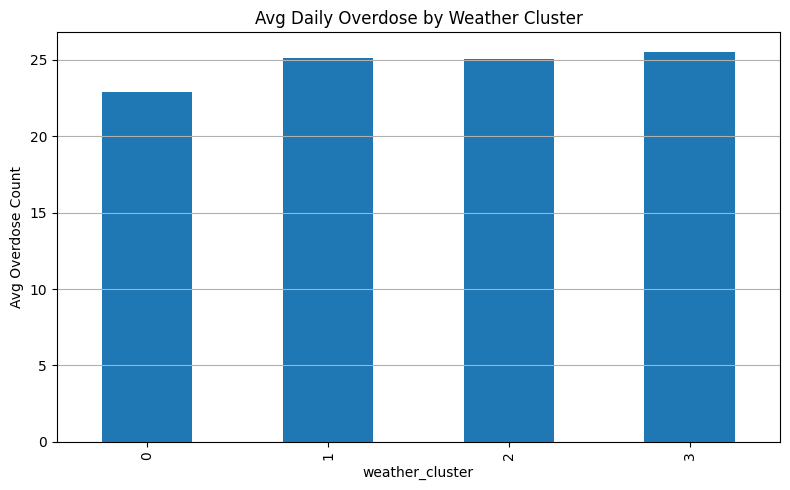

In [ ]:
# Average overdose count per cluster
cluster_avg = daily_overdose_ts.groupby("weather_cluster")["incident_count"].mean()
cluster_avg.plot(kind="bar", figsize=(8, 5), title="Avg Daily Overdose by Weather Cluster")
plt.ylabel("Avg Overdose Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


SARIMAX w/ Cluster as the Exogenous Feature

In [ ]:
# Add cluster dummies to exog_enhanced
cluster_dummies = pd.get_dummies(daily_overdose_ts["weather_cluster"], prefix="cluster", drop_first=True)
exog_enhanced_cluster = pd.concat([exog_enhanced, cluster_dummies], axis=1)

# Drop any NaNs, align
combined = pd.concat([daily_overdose_ts["incident_count"], exog_enhanced_cluster], axis=1).dropna()
aligned_target_cluster = combined["incident_count"]
exog_cluster_model = combined.drop(columns=["incident_count"])


# If 'date' is a column, not index:
# exog_cluster_model['date'] = pd.to_datetime(exog_cluster_model['date'])
# exog_cluster_model.set_index('date', inplace=True)

# If already index, convert it to datetime index
exog_cluster_model.index = pd.to_datetime(exog_cluster_model.index)

# Also ensure the target variable index is datetime
aligned_target_cluster.index = pd.to_datetime(aligned_target_cluster.index)

# Ensure all exogenous variables are numeric
exog_cluster_model = exog_cluster_model.apply(pd.to_numeric, errors='raise')


# Convert boolean columns to integers
for col in exog_cluster_model.select_dtypes(include='bool').columns:
    exog_cluster_model[col] = exog_cluster_model[col].astype(int)


# Fit SARIMAX with cluster features
model_cluster = SARIMAX(
    aligned_target_cluster,
    order=(3, 1, 3),
    seasonal_order=(1, 0, 1, 7),
    exog=exog_cluster_model
)
results_cluster = model_cluster.fit()
print(results_cluster.summary())

# Evaluate
mae = mean_absolute_error(aligned_target_cluster, results_cluster.fittedvalues)
rmse = np.sqrt(mean_squared_error(aligned_target_cluster, results_cluster.fittedvalues))
print(f"Cluster SARIMAX — MAE: {mae:.2f}, RMSE: {rmse:.2f}")


                                      SARIMAX Results                                      
Dep. Variable:                      incident_count   No. Observations:                 1819
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 7)   Log Likelihood               -5032.587
Date:                             Wed, 11 Jun 2025   AIC                          10125.175
Time:                                     12:29:15   BIC                          10290.340
Sample:                                 01-09-2020   HQIC                         10186.113
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0229      0.014      1.584      0.113      -0.005    

SARIMAX with Separate Time Series per Cluster

✅ Cluster 0 — AIC: 5421.22


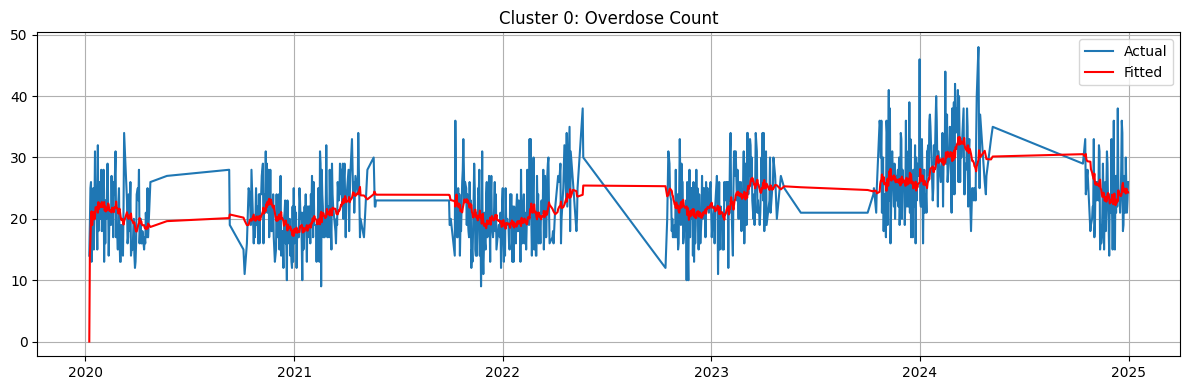

✅ Cluster 1 — AIC: 5553.00


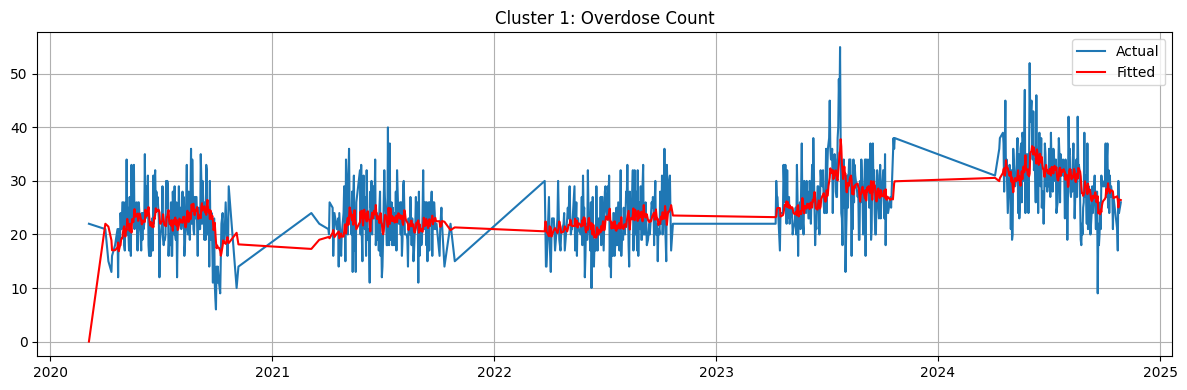

⏭️ Cluster 2 skipped (only 50 days)
⏭️ Cluster 3 skipped (only 15 days)


In [ ]:
for cluster_id in sorted(daily_overdose_ts["weather_cluster"].unique()):
    cluster_subset = daily_overdose_ts[daily_overdose_ts["weather_cluster"] == cluster_id].copy()
    
    if len(cluster_subset) < 100:
        print(f"⏭️ Cluster {cluster_id} skipped (only {len(cluster_subset)} days)")
        continue

    y = cluster_subset["incident_count"]

    try:
        model = SARIMAX(y, order=(2, 1, 1))
        results = model.fit()
        print(f"✅ Cluster {cluster_id} — AIC: {results.aic:.2f}")
        
        # Optional: plot
        plt.figure(figsize=(12, 4))
        plt.plot(y.index, y, label="Actual")
        plt.plot(results.fittedvalues.index, results.fittedvalues, label="Fitted", color="red")
        plt.title(f"Cluster {cluster_id}: Overdose Count")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Cluster {cluster_id} failed: {e}")


# Final Eval

In [ ]:
# Add cluster dummies
cluster_dummies = pd.get_dummies(daily_overdose_ts["weather_cluster"], prefix="cluster", drop_first=True)

# Add to your engineered feature set
exog_enhanced_cluster = pd.concat([exog_enhanced, cluster_dummies], axis=1)


In [ ]:
# Join with target, drop rows with NA
combined_cluster = pd.concat([daily_overdose_ts["incident_count"], exog_enhanced_cluster], axis=1).dropna()

aligned_target_clustered = combined_cluster["incident_count"]
exog_enhanced_cluster = combined_cluster.drop(columns=["incident_count"])


In [ ]:
# Convert any object/bool types to numeric
exog_enhanced_cluster = exog_enhanced_cluster.apply(pd.to_numeric, errors="raise")


In [ ]:
# 1. Remove duplicate columns (if rerunning cells)
exog_enhanced_cluster = exog_enhanced_cluster.loc[:, ~exog_enhanced_cluster.columns.duplicated()]

# 2. Convert all boolean columns to integers
bool_cols = exog_enhanced_cluster.select_dtypes(include="bool").columns
exog_enhanced_cluster[bool_cols] = exog_enhanced_cluster[bool_cols].astype(int)

# 3. Final check and enforce numeric
exog_enhanced_cluster = exog_enhanced_cluster.apply(pd.to_numeric, errors="raise")

# 4. Assert it's clean
assert exog_enhanced_cluster.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all(), "❌ Non-numeric values remain!"


In [ ]:
sarimax_clustered = SARIMAX(
    aligned_target_clustered,
    order=(3, 1, 3),
    seasonal_order=(1, 0, 1, 7),
    exog=exog_enhanced_cluster
)
results_clustered = sarimax_clustered.fit()
print(results_clustered.summary())


                                      SARIMAX Results                                      
Dep. Variable:                      incident_count   No. Observations:                 1819
Model:             SARIMAX(3, 1, 3)x(1, 0, [1], 7)   Log Likelihood               -5032.587
Date:                             Wed, 11 Jun 2025   AIC                          10125.175
Time:                                     12:29:24   BIC                          10290.340
Sample:                                 01-09-2020   HQIC                         10186.113
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
apparent_temperature_f     0.0229      0.014      1.584      0.113      -0.005    

In [ ]:
mae = mean_absolute_error(aligned_target_clustered, results_clustered.fittedvalues)
rmse = np.sqrt(mean_squared_error(aligned_target_clustered, results_clustered.fittedvalues))
print(f"📊 Cluster-Enhanced SARIMAX — MAE: {mae:.2f}, RMSE: {rmse:.2f}")


📊 Cluster-Enhanced SARIMAX — MAE: 3.11, RMSE: 4.04
